# ARIMA model

In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Load the data
df = pd.read_csv("data/Daily.csv")
df = df[["Date", "USD"]]
df['USD'] = df['USD'].str.replace(',', '')
df["USD"] = pd.to_numeric(df["USD"])
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y") # Parse dates
df = df[df["Date"] >= "2010-01-01"]
df = df.dropna()
df = df.reset_index(drop=True) # Sort by date
df = df.set_index("Date") # Set date as index

In [3]:
trading_days_per_year = 252

C:\Users\Ryan Joo\AppData\Local\Temp\ipykernel_2780\1756641383.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


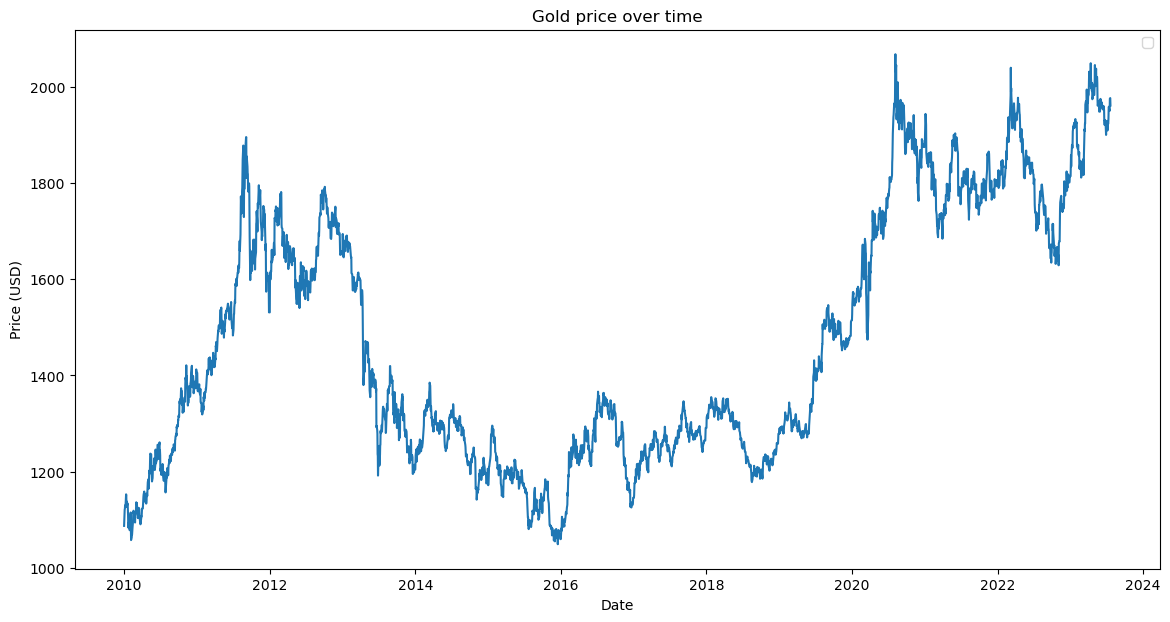

In [4]:
# Create a time plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["USD"])
plt.title(f'Gold price over time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [5]:
# Check for stationarity
result_original = adfuller(df["USD"])
p_value_original = result_original[1]
print(f"p-value: {p_value_original:.4f}")
if p_value_original < 0.05: # compare p-value with sig level
    print("The original series is stationary")
else:
    print("The original series is non-stationary")

p-value: 0.6573
The original series is non-stationary


In [6]:
# Repeatedly difference the time series until it becomes stationary
d = 0
df["Gold_diff"] = df["USD"]
p_value_diff = p_value_original

while p_value_diff >= 0.05:
    # Apply differencing
    df["Gold_diff"] = df["Gold_diff"].diff()

    # Perform Augmented Dickey-Fuller test on the differenced series
    result_diff = adfuller(df["Gold_diff"].dropna())
    p_value_diff = result_diff[1]
    d += 1

print(f"Value of d: {d}")
print(p_value_diff)

Value of d: 1
8.57443325934296e-25


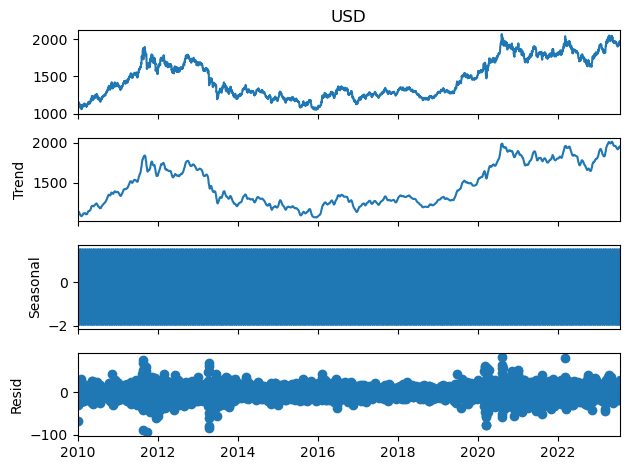

In [7]:
# Check for seasonality by performing classical decomposition
import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(df["USD"], model='additive', extrapolate_trend='freq', period=12)
fig = decomposition.plot()
plt.show()

In [8]:
trend = decomposition.trend.dropna()

In [ ]:
# Forecasting
test_period = trading_days_per_year * 5
train_period = len(trend) - test_period
window_size = trading_days_per_year

model = pm.auto_arima(
    trend.iloc[:train_period], 
    start_p=0, max_p=5, 
    start_q=0, max_q=5,
    d=d,
    seasonal=False,
    trace=True, 
    error_action='ignore', 
    suppress_warnings=True,
    stepwise=True
)

In [ ]:
best_order = model.order
model = ARIMA(trend.iloc[:train_period], order=best_order)
model_fit = model.fit()

In [ ]:
# Use a rolling window
# i.e. use past 1 year's data to predict tomorrow's price
forecast = pd.Series()
 
for t in range(train_period, len(trend)):
    next_forecast = model_fit.forecast(steps=1)
    forecast = pd.concat([forecast, next_forecast])
    
    start_idx = t - window_size + 1
    end_idx = t + 1
    current_window = trend.iloc[start_idx:end_idx]
    
    model_fit = model_fit.apply(current_window, refit=False)

In [33]:
# Backtest trading
transaction_cost = 0.5 / 100 # 0.5%

train = df["USD"].iloc[:train_period]
test = df["USD"].iloc[train_period:]

# % price change
test_data = test.to_frame()
test_data["Actual % change"] = test_data["USD"].pct_change()
forecast_price = forecast[:len(test)]
test_data["Forecast price"] = list(forecast_price)
test_data["Expected % return"] = (test_data["Forecast price"] - test_data["USD"].shift(1)) / test_data["USD"].shift(1)

In [34]:
# Given today's position and the predicted percentage change in price,
# returns the position for tomorrow
def get_position(current_position: int, delta_p: float):
    
    t = transaction_cost
    
    match current_position:
        case 1: # current long
            if delta_p >= 0:
                return 1
            else:
                options = {
                    1: delta_p,
                    0: -t,
                    -1: -delta_p - 2*t
                }
                return max(options, key=options.get)

        case -1: # current short
            if delta_p <= 0:
                return -1
            else:
                options = {
                    -1: -delta_p,
                    0: -t,
                    1: delta_p - 2*t
                }
                return max(options, key=options.get)
            
        case 0: # current no position
            if delta_p > t:
                return 1
            elif -delta_p > t:
                return -1
            else:
                return 0

test_data["Position"] = np.nan

position_idx = test_data.columns.get_loc("Position")
expected_idx = test_data.columns.get_loc("Expected % return")

test_data.iloc[0, position_idx] = 0

for i in range(1, len(test_data)):
    current_position = test_data.iloc[i-1, position_idx]
    delta_p = test_data.iloc[i, expected_idx]
    
    test_data.iloc[i, position_idx] = get_position(current_position, delta_p)

Net return percentage of today's trade can be calculated as

$$\begin{aligned}
\text{Net return \%}
&=\text{Return \%}-\text{Total transaction cost \%}\\
&=\text{Position}\times\text{\% actual change in price}-\text{Number of transactions}\times\text{Transaction cost \%}
\end{aligned}$$

where the number of transactions can be calculated as the absolute value of difference between yesterday's position and today's position.

In [35]:
# Computes the net percentage return of a day's trade,
# taking into account the transaction cost
def get_net_return(previous_position: int, current_position: int, actual_pct_change: float):
    change_in_position = abs(previous_position - current_position) # number of transactions
    cost = change_in_position * transaction_cost # total transaction cost incurred
    return current_position * actual_pct_change - cost

test_data["Net % return"] = np.nan

return_idx = test_data.columns.get_loc("Net % return")
pct_change_idx = test_data.columns.get_loc("Actual % change")

for i in range(1, len(test_data)):
    previous_position = test_data.iloc[i-1, position_idx]
    current_position = test_data.iloc[i, position_idx]
    actual_pct_change = test_data.iloc[i, pct_change_idx]
    
    test_data.iloc[i, return_idx] = get_net_return(previous_position, current_position, actual_pct_change)

In [36]:
# Cumulative returns
initial_capital = 1_000_000
portion = 0.10
invested_capital = initial_capital * portion

test_data["Strategy returns"] = test_data["Net % return"] * invested_capital
test_data["Cumulative strategy returns"] = test_data["Strategy returns"].cumsum()

test_data["Actual returns"] = test_data["Actual % change"] * invested_capital
test_data["Cumulative actual returns"] = test_data["Actual returns"].cumsum()

# Make graph start at 0
start_date = test_data.index[0] - pd.Timedelta(days=1)
start_df = pd.DataFrame(data={"PnL": 0.0}, index=[start_date])
strategy_pnl = pd.concat([start_df, test_data[["Cumulative strategy returns"]]])
actual_pnl = pd.concat([start_df, test_data[["Cumulative actual returns"]]])

test_data.dropna(inplace=True)

In [37]:
test_data

,USD,Actual % change,Forecast price,Expected % return,Position,Net % return,Strategy returns,Cumulative strategy returns,Actual returns,Cumulative actual returns
Date,,,,,,,,,,
2018-09-25,1201.9,-0.000748,1197.831300,-0.004131,0.0,-0.000000,-0.000000,0.000000,-74.825407,-74.825407
2018-09-26,1194.3,-0.006323,1198.407439,-0.002906,0.0,-0.000000,-0.000000,0.000000,-632.332141,-707.157548
2018-09-27,1185.4,-0.007452,1198.263348,0.003319,0.0,-0.000000,-0.000000,0.000000,-745.206397,-1452.363945
2018-09-28,1187.3,0.001603,1198.632626,0.011163,1.0,-0.003397,-339.716551,-339.716551,160.283449,-1292.080497
2018-10-01,1189.4,0.001769,1196.162667,0.007465,1.0,0.001769,176.871894,-162.844657,176.871894,-1115.208602
...,...,...,...,...,...,...,...,...,...,...
2023-07-17,1949.6,-0.002099,1934.414720,-0.009871,-1.0,-0.007901,-790.141782,279807.813339,-209.858218,53704.902793
2023-07-18,1975.0,0.013028,1954.175291,0.002347,-1.0,-0.013028,-1302.831350,278504.981989,1302.831350,55007.734143
2023-07-19,1975.4,0.000203,1945.283179,-0.015046,-1.0,-0.000203,-20.253165,278484.728825,20.253165,55027.987307


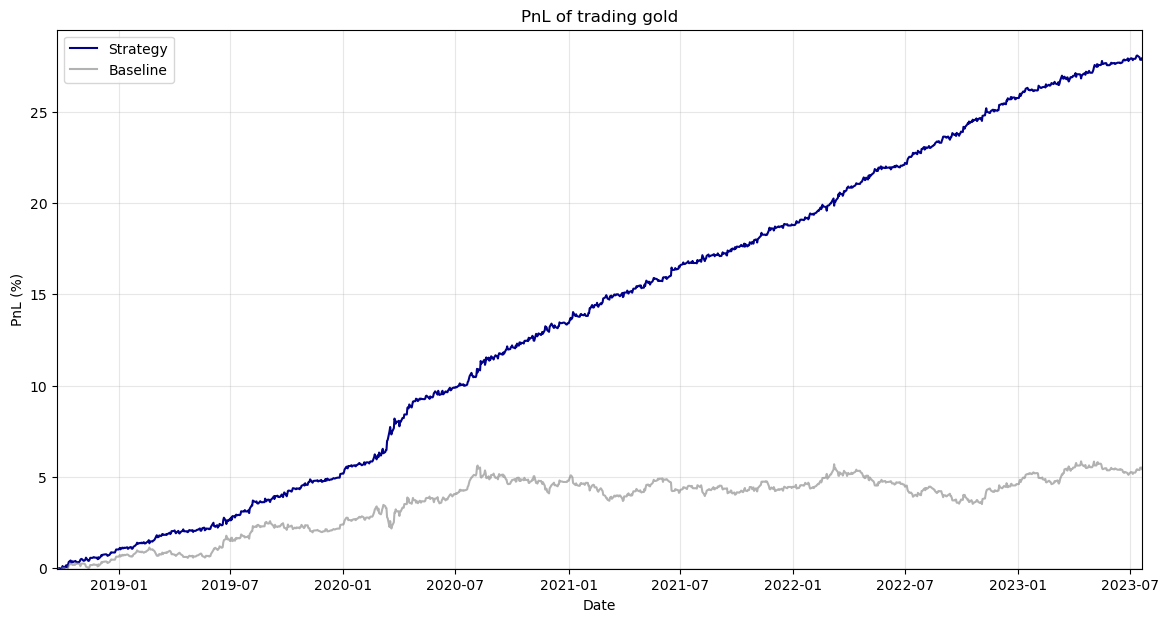

In [41]:
# Plot PnL chart
strategy_cul_rate_returns = strategy_pnl["Cumulative strategy returns"] / initial_capital * 100
actual_cul_rate_returns = actual_pnl["Cumulative actual returns"] / initial_capital * 100
plt.figure(figsize=(14,7))
plt.plot(strategy_pnl.index, strategy_cul_rate_returns, label='Strategy', color='darkblue')
plt.plot(actual_pnl.index, actual_cul_rate_returns, label='Baseline', color='grey', alpha=0.6) # Baseline: buy and hold
plt.xlim(min(strategy_pnl.index), max(strategy_pnl.index))
plt.ylim(strategy_cul_rate_returns.min(), None)
plt.title(f"PnL of trading gold")
plt.xlabel("Date")
plt.ylabel("PnL (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
# Returns performance metrics of the trading strategy
def get_metrics(df):
    
    metric_names = [
        "Cumulative rate of return",
        "Annualised rate of return",
        "Win rate",
        "Average win/loss ratio",
        "Profit factor",
        "Sharpe ratio",
        "Maximum drawdown"
    ]
    
    metrics = dict.fromkeys(metric_names, "")
    
    # Cumulative rate of return
    final_pnl = df["Cumulative strategy returns"].iloc[-1]
    cum_return_pct = final_pnl / initial_capital
    metrics["Cumulative rate of return"] = f"{cum_return_pct * 100:.2f}%"

    # Annualised rate of return
    total_days = len(df)
    num_years = total_days / trading_days_per_year
    annual_return_pct = cum_return_pct / num_years
    metrics["Annualised rate of return"] = f"{annual_return_pct * 100:.2f}%"

    # Win rate
    up_days = df[df["Strategy returns"] > 0]
    down_days = df[df["Strategy returns"] < 0]
    neutral_days = df[df["Strategy returns"] == 0]
    win_rate = len(up_days) / total_days
    metrics["Win rate"] = f"{win_rate * 100:.2f}%"

    # Average win/loss ratio
    avg_profit = up_days["Strategy returns"].mean()
    avg_loss = abs(down_days["Strategy returns"].mean())
    avg_win_loss_ratio = avg_profit / avg_loss
    metrics["Average win/loss ratio"] = f"{avg_win_loss_ratio:.2f}"

    # Profit factor
    gross_profit = up_days["Strategy returns"].sum()
    gross_loss = abs(down_days["Strategy returns"].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan
    metrics["Profit factor"] = f"{profit_factor:.2f}"

    # Sharpe ratio
    return_mean = df["Strategy returns"].mean()
    return_std = df["Strategy returns"].std()
    sharpe_ratio = (return_mean / return_std) * np.sqrt(trading_days_per_year)
    metrics["Sharpe ratio"] = f"{sharpe_ratio:.2f}"

    # Maximum drawdown
    def max_dd(ser):
        max_so_far = ser.cummax() # list of maximums up to each point
        dd_so_far = ser - max_so_far
        return int(dd_so_far.min())
    max_drawdown = max_dd(df["Strategy returns"])
    metrics["Maximum drawdown"] = f"{max_drawdown}"

    res = [f"Performance metrics of trading gold"] + ["-------------------------------------"] + [f"{key}: {value}" for key, value in metrics.items()]
 
    return "\n".join(res)

In [40]:
# Get backtest results
print(get_metrics(test_data))

Performance metrics of trading gold
-------------------------------------
Cumulative rate of return: 27.92%
Annualised rate of return: 5.59%
Win rate: 57.51%
Average win/loss ratio: 1.27
Profit factor: 1.91
Sharpe ratio: 3.67
Maximum drawdown: -9203
